# Probability Distribution Functions 

In [43]:
# Setup: Load module and packages
include(joinpath(dirname(pwd()), "src", "VoterResetting.jl"))
using .VoterResetting
using Graphs: erdos_renyi, barabasi_albert, random_regular_graph
using Plots

default(size = (900, 400), legend = :topright, linewidth = 2)

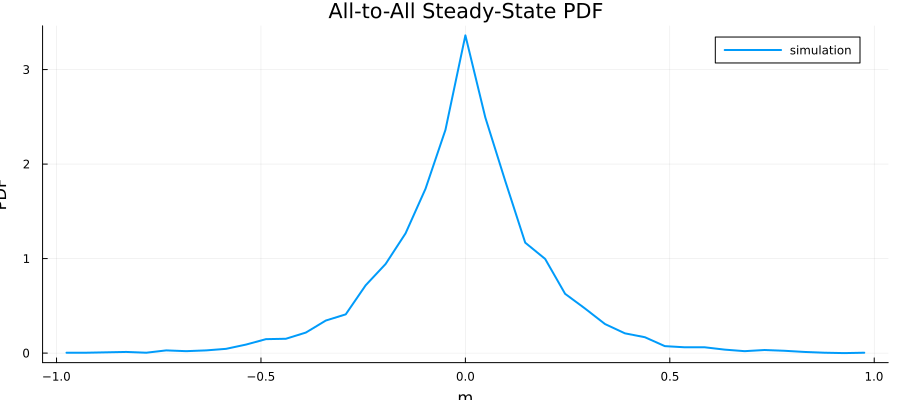

In [44]:
all_to_all_params = VoterResetting.AllToAllParams(500, 0.1, 0.0)
all_to_all_result = VoterResetting.simulate_pdf_all_to_all(
    all_to_all_params;
    reset = VoterResetting.delta_reset(0.0),
    times = [500.0],
    bins = 41,
    nsamples = 5000,
)

plot(
    all_to_all_result.bin_centers,
    vec(all_to_all_result.densities[1, :]);
    xlabel = "m",
    ylabel = "PDF",
    title = "All-to-All Steady-State PDF",
    label = "simulation",
)

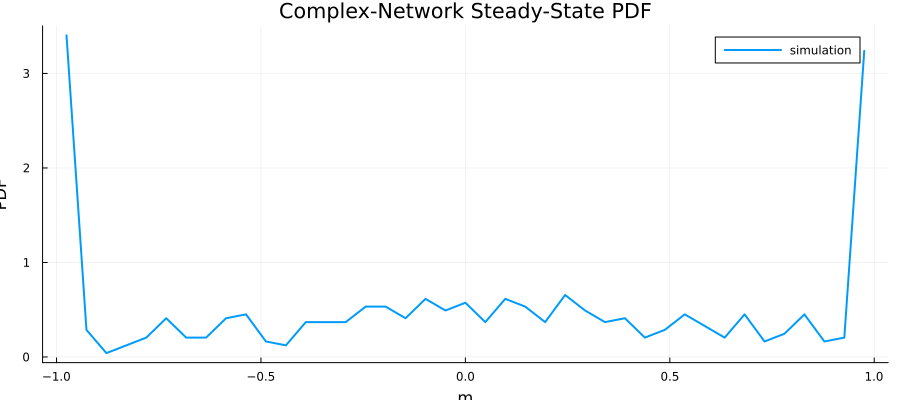

In [45]:
complex_graph = erdos_renyi(300, 0.05)
complex_params = VoterResetting.ComplexParams(0.1, 0.0)
complex_result = VoterResetting.simulate_pdf_complex(
    complex_graph,
    complex_params;
    reset = VoterResetting.hub_reset(0.0),
    times = [200.0],
    bins = 41,
    nsamples = 500,
)

plot(
    complex_result.bin_centers,
    vec(complex_result.densities[1, :]);
    xlabel = "m",
    ylabel = "PDF",
    title = "Complex-Network Steady-State PDF",
    label = "simulation",
)

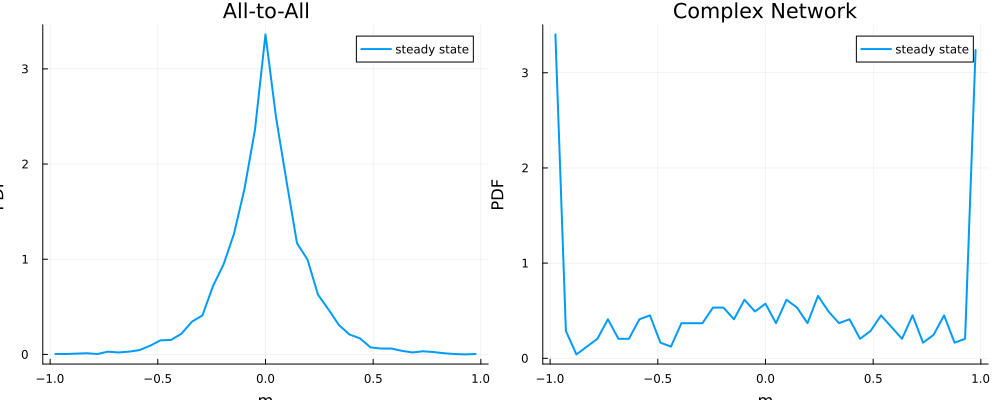

In [46]:
plot(
    plot(
        all_to_all_result.bin_centers,
        vec(all_to_all_result.densities[1, :]);
        xlabel = "m",
        ylabel = "PDF",
        title = "All-to-All",
        label = "steady state",
    ),
    plot(
        complex_result.bin_centers,
        vec(complex_result.densities[1, :]);
        xlabel = "m",
        ylabel = "PDF",
        title = "Complex Network",
        label = "steady state",
    );
    layout = (1, 2),
    size = (1000, 400),
)

# First Passage Time Analysis
Visualizing the distribution of times to reach consensus under different conditions.

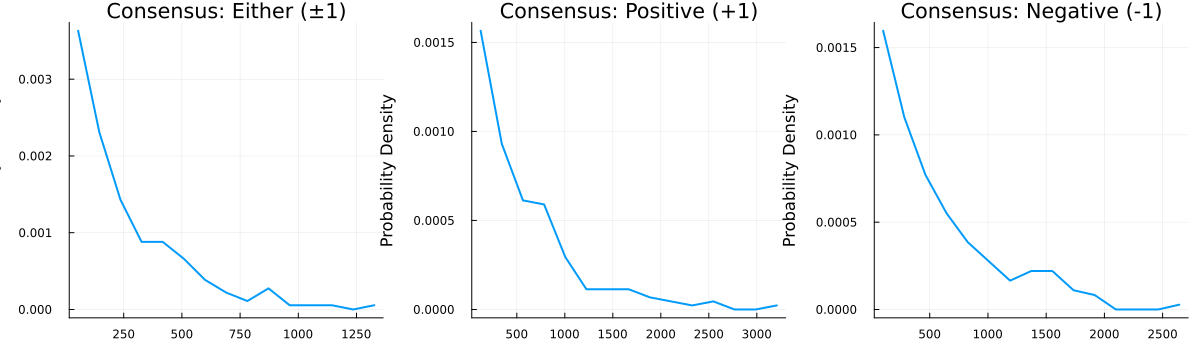

In [47]:
# FPT for different consensus types
fpt_params = VoterResetting.AllToAllParams(100, 0.1, 0.0)

fpt_either = VoterResetting.first_passage_time_all_to_all(
    fpt_params;
    consensus_type = :either,
    nsamples = 200,
)

fpt_positive = VoterResetting.first_passage_time_all_to_all(
    fpt_params;
    consensus_type = :positive,
    nsamples = 200,
)

fpt_negative = VoterResetting.first_passage_time_all_to_all(
    fpt_params;
    consensus_type = :negative,
    nsamples = 200,
)

plot(
    plot(
        fpt_either.bin_centers,
        fpt_either.densities;
        xlabel = "Time",
        ylabel = "Probability Density",
        title = "Consensus: Either (±1)",
        label = "N=100, r=0.1",
        legend = false,
    ),
    plot(
        fpt_positive.bin_centers,
        fpt_positive.densities;
        xlabel = "Time",
        ylabel = "Probability Density",
        title = "Consensus: Positive (+1)",
        label = "N=100, r=0.1",
        legend = false,
    ),
    plot(
        fpt_negative.bin_centers,
        fpt_negative.densities;
        xlabel = "Time",
        ylabel = "Probability Density",
        title = "Consensus: Negative (-1)",
        label = "N=100, r=0.1",
        legend = false,
    );
    layout = (1, 3),
    size = (1200, 350),
)

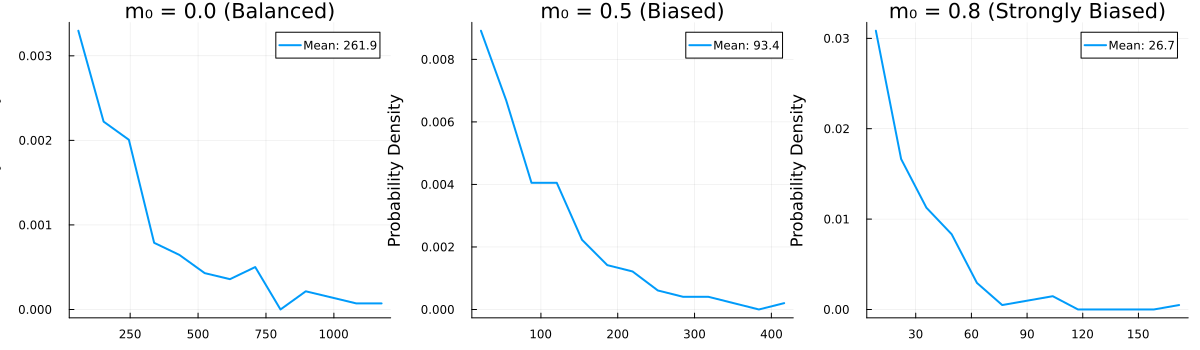

In [48]:
# Effect of initial magnetization on FPT
m0_values = [0.0, 0.5, 0.8]
fpt_m0_results = []

for m0 in m0_values
    params_m0 = VoterResetting.AllToAllParams(100, 0.1, m0)
    result_m0 = VoterResetting.first_passage_time_all_to_all(
        params_m0;
        consensus_type = :either,
        nsamples = 150,
    )
    push!(fpt_m0_results, result_m0)
end

plot(
    plot(
        fpt_m0_results[1].bin_centers,
        fpt_m0_results[1].densities;
        xlabel = "Time",
        ylabel = "Probability Density",
        title = "m₀ = 0.0 (Balanced)",
        label = "Mean: $(round(fpt_m0_results[1].mean_fpt; digits=1))",
    ),
    plot(
        fpt_m0_results[2].bin_centers,
        fpt_m0_results[2].densities;
        xlabel = "Time",
        ylabel = "Probability Density",
        title = "m₀ = 0.5 (Biased)",
        label = "Mean: $(round(fpt_m0_results[2].mean_fpt; digits=1))",
    ),
    plot(
        fpt_m0_results[3].bin_centers,
        fpt_m0_results[3].densities;
        xlabel = "Time",
        ylabel = "Probability Density",
        title = "m₀ = 0.8 (Strongly Biased)",
        label = "Mean: $(round(fpt_m0_results[3].mean_fpt; digits=1))",
    );
    layout = (1, 3),
    size = (1200, 350),
)

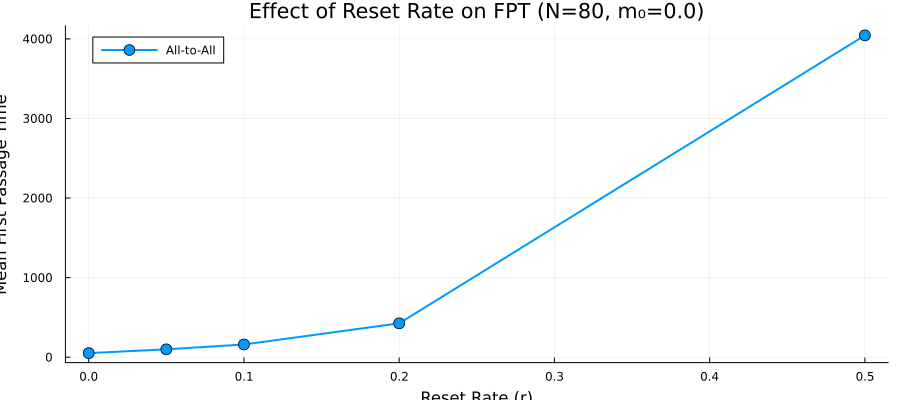

In [49]:
# Effect of reset rate on mean FPT
reset_rates = [0.0, 0.05, 0.1, 0.2, 0.5]
mean_fpts = []

for r in reset_rates
    params_r = VoterResetting.AllToAllParams(80, r, 0.0)
    result_r = VoterResetting.first_passage_time_all_to_all(
        params_r;
        consensus_type = :either,
        nsamples = 100,
    )
    push!(mean_fpts, result_r.mean_fpt)
end

plot(
    reset_rates,
    mean_fpts;
    xlabel = "Reset Rate (r)",
    ylabel = "Mean First Passage Time",
    title = "Effect of Reset Rate on FPT (N=80, m₀=0.0)",
    marker = :circle,
    markersize = 6,
    label = "All-to-All",
    legend = :topleft,
)

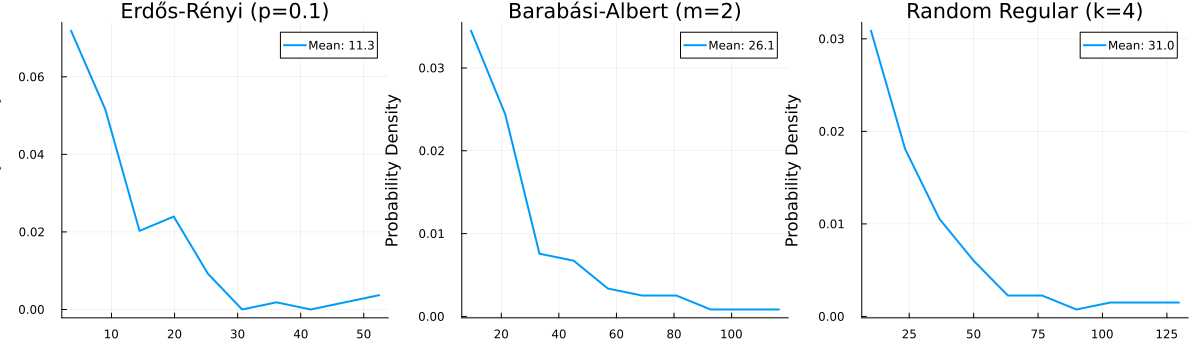

In [50]:
# FPT on different network topologies
G_er = erdos_renyi(80, 0.1)
G_ba = barabasi_albert(80, 2)
G_rg = random_regular_graph(80, 4)

params_complex = VoterResetting.ComplexParams(0.1, 0.0)

fpt_er = VoterResetting.first_passage_time_complex(
    G_er,
    params_complex;
    consensus_type = :either,
    nsamples = 100,
)

fpt_ba = VoterResetting.first_passage_time_complex(
    G_ba,
    params_complex;
    consensus_type = :either,
    nsamples = 100,
)

fpt_rg = VoterResetting.first_passage_time_complex(
    G_rg,
    params_complex;
    consensus_type = :either,
    nsamples = 100,
)

plot(
    plot(
        fpt_er.bin_centers,
        fpt_er.densities;
        xlabel = "Time",
        ylabel = "Probability Density",
        title = "Erdős-Rényi (p=0.1)",
        label = "Mean: $(round(fpt_er.mean_fpt; digits=1))",
    ),
    plot(
        fpt_ba.bin_centers,
        fpt_ba.densities;
        xlabel = "Time",
        ylabel = "Probability Density",
        title = "Barabási-Albert (m=2)",
        label = "Mean: $(round(fpt_ba.mean_fpt; digits=1))",
    ),
    plot(
        fpt_rg.bin_centers,
        fpt_rg.densities;
        xlabel = "Time",
        ylabel = "Probability Density",
        title = "Random Regular (k=4)",
        label = "Mean: $(round(fpt_rg.mean_fpt; digits=1))",
    );
    layout = (1, 3),
    size = (1200, 350),
)